# Lire le dataset issu de l'étape cleaning

In [78]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Charger le dataset après cleaning
df = pd.read_csv('../data/processed/step2_cleaning.csv')

# Vérification rapide
print("Shape du dataset :", df.shape)
df.head()


Shape du dataset : (4372, 54)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ProductDiversity,Gender,AccountStatus,Country,Churn,MonetaryTotal_log,RegYear,RegMonth,RegDay,RegWeekday
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,Explorateur,Unknown,Active,United Kingdom,1,8.573504,2010,7,17,5
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,Explorateur,M,Active,United Kingdom,0,8.032717,2010,4,10,5
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Explorateur,Unknown,Active,France,0,8.880216,2009,9,12,5
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,Explorateur,Unknown,Active,United Kingdom,1,6.855672,2010,1,28,3
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,Spécialisé,M,Active,United Kingdom,1,6.455356,2009,10,12,0


1. Analyse rapide des colonnes

In [79]:
# Colonnes numériques
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Colonnes numériques :", num_cols)

# Colonnes catégorielles
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("Colonnes catégorielles :", cat_cols)


Colonnes numériques : ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn', 'MonetaryTotal_log', 'RegYear', 'RegMonth', 'RegDay', 'RegWeekday']
Colonnes catégorielles : ['RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Cou

C:\Users\chaie\AppData\Local\Temp\ipykernel_16284\4015174587.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()


# 2. Création de nouvelles features numériques

# 1. Features basiques

1.1 Dépense par jour

In [80]:
df['MonetaryPerDay'] = df['MonetaryTotal'] / (df['Recency'] + 1)
#client dépense combien par jour => client dépense combien par jour

1.2 Panier moyen amélioré

In [81]:
df['AvgBasketValue'] = df['MonetaryTotal'] / (df['Frequency'] + 1)
#taille moyenne du panier => client VIP vs petit client

1.3 Intensité d’achat

In [82]:
df['PurchaseIntensity'] = df['Frequency'] / (df['CustomerTenureDays'] + 1)
#fréquence d’achat dans le temps => client fidèle ou pas

1.4 Ratio récence / ancienneté

In [83]:
df['TenureRatio'] = df['Recency'] / (df['CustomerTenureDays'] + 1)
#compare ancienneté vs activité récente => détecter churn 

# Visualisation des distributions

In [84]:
df[['MonetaryTotal', 'Recency', 'MonetaryPerDay',
    'Frequency', 'AvgBasketValue',
    'PurchaseIntensity', 'TenureRatio']].head(10)

,MonetaryTotal,Recency,MonetaryPerDay,Frequency,AvgBasketValue,PurchaseIntensity,TenureRatio
0,5288.63,302,17.454224,35,146.906389,0.486111,4.194444
1,3079.10,32,93.306061,18,162.057895,0.052478,0.093294
2,7187.34,3,1796.835000,18,378.281053,0.048518,0.008086
3,948.25,96,9.775773,5,158.041667,0.017921,0.344086
4,635.10,330,1.918731,6,90.728571,0.136364,7.500000
5,4596.51,26,170.241111,20,218.881429,0.057307,0.074499
6,5107.38,8,567.486667,27,182.406429,0.073569,0.021798
7,4627.62,16,272.212941,15,289.226250,0.041899,0.044693
8,59419.34,1,29709.670000,118,499.322185,0.315508,0.002674
9,7711.38,3,1927.845000,86,88.636552,0.231183,0.008065


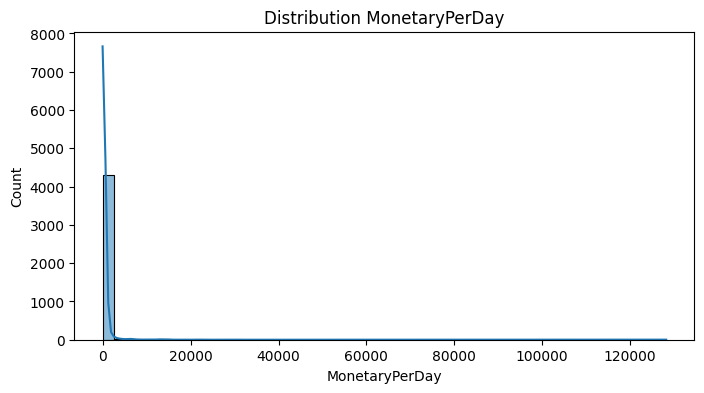

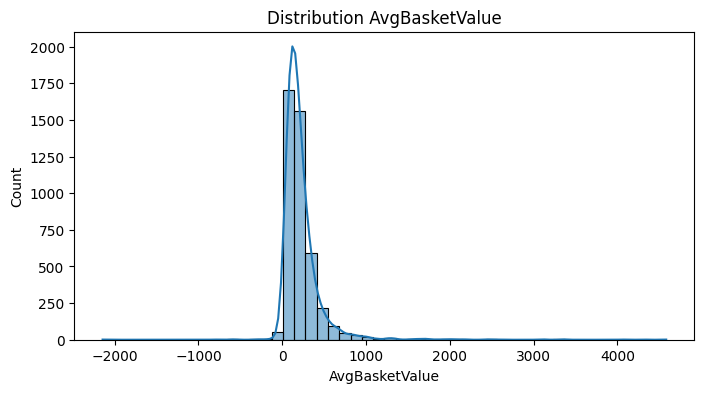

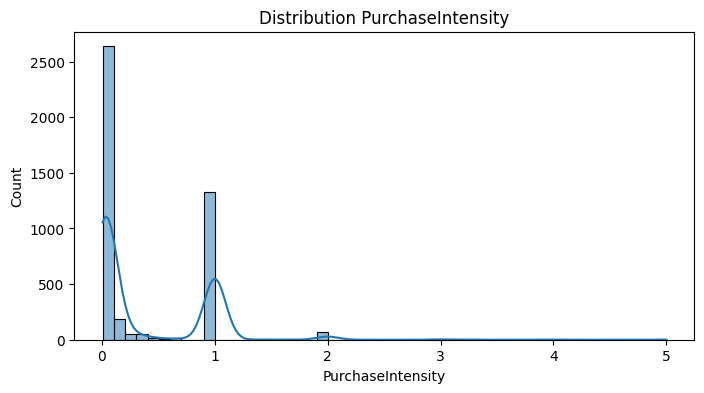

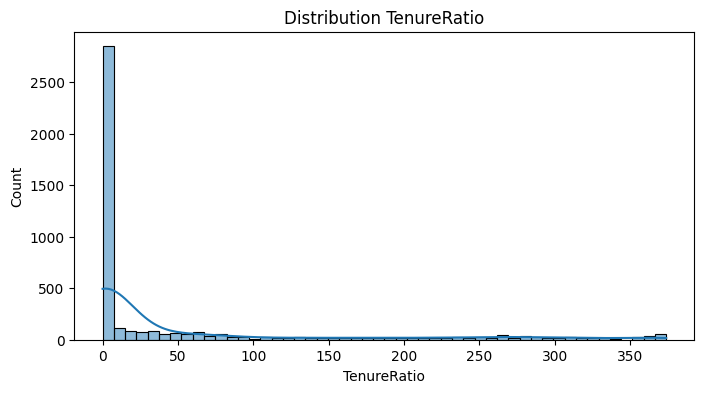

In [85]:
features_to_plot = ['MonetaryPerDay','AvgBasketValue','PurchaseIntensity','TenureRatio']

for col in features_to_plot:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution {col}")
    plt.show()

    #pour tenureratio #valeur élevée = client inactif ⚠️


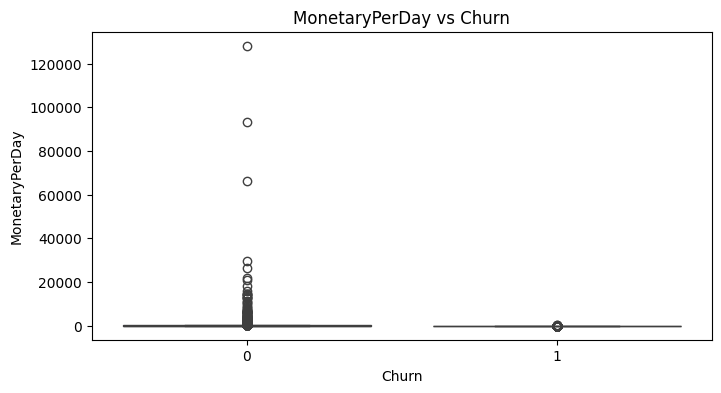

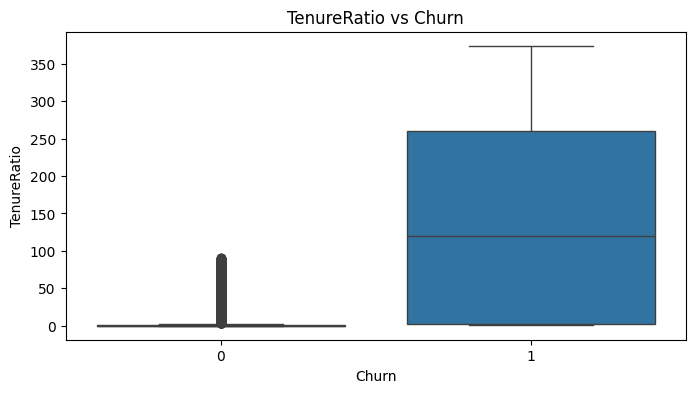

In [86]:
# Boxplots vs Churn
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='MonetaryPerDay', data=df)
plt.title("MonetaryPerDay vs Churn")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='TenureRatio', data=df)
plt.title("TenureRatio vs Churn")
plt.show()


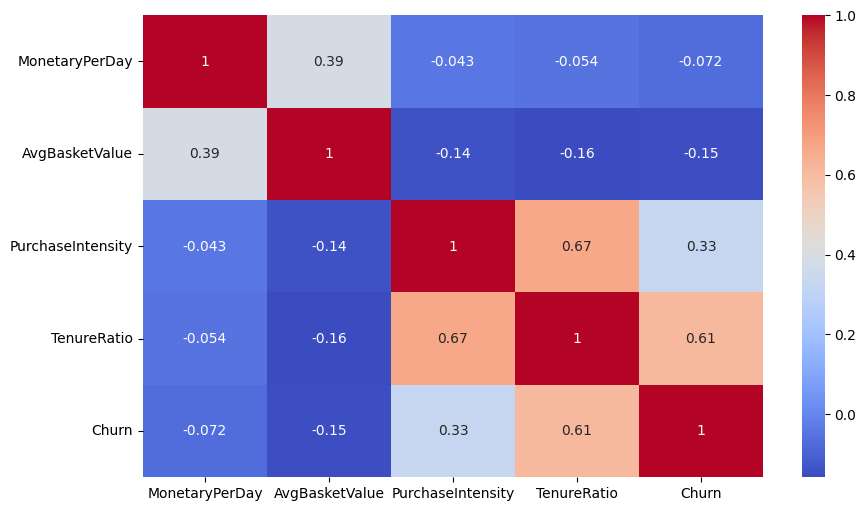

In [87]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['MonetaryPerDay','AvgBasketValue',
                'PurchaseIntensity','TenureRatio','Churn']].corr(),
            annot=True, cmap='coolwarm')
plt.show()


# 2. Features comportementales

2.1 Diversité produits

In [88]:
df['ProductDiversityRatio'] = df['UniqueProducts'] / (df['Frequency'] + 1)
#diversité des produits achetés => client qui achète toujours les mêmes produits vs client qui varie

2.2 Impact des retours

In [89]:
df['ReturnImpact'] = df['ReturnRatio'] * df['MonetaryTotal']
#impact des retours sur la valeur du client => client qui fait beaucoup de retours et dépense beaucoup = client à risque

2.3 Engagement client

In [90]:
df['EngagementScore'] = (df['Frequency']+df['TotalQuantity']+df['UniqueProducts']) 
#score d’engagement global => client très actif vs client peu actif
df['EngagementScoreNormalized'] = df['EngagementScore'] / df['CustomerTenureDays']
#normaliser par ancienneté pour éviter biais

2.4 Score client

In [91]:
df['CustomerScore'] = (df['Frequency']*0.4 + df['MonetaryTotal']*0.4 + df['Recency']*0.2)
#score global pondéré => client à fort potentiel vs client à faible potentiel
df['CustomerScoreNormalized'] = df['CustomerScore'] / df['CustomerTenureDays']
#normaliser par ancienneté pour éviter biais

In [92]:
df.head(10)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,MonetaryPerDay,AvgBasketValue,PurchaseIntensity,TenureRatio,ProductDiversityRatio,ReturnImpact,EngagementScore,EngagementScoreNormalized,CustomerScore,CustomerScoreNormalized
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,17.454224,146.906389,0.486111,4.194444,0.666667,254.261058,1752,24.676056,2189.852,30.842986
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,93.306061,162.057895,0.052478,0.093294,5.578947,377.032653,1479,4.324561,1245.240,3.641053
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,1796.835000,378.281053,0.048518,0.008086,6.052632,114.539283,5142,13.897297,2882.736,7.791178
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,9.775773,158.041667,0.017921,0.344086,4.000000,0.000000,468,1.683453,400.500,1.440647
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,1.918731,90.728571,0.136364,7.500000,0.142857,317.550000,65,1.511628,322.440,7.498605
5,15291,26,20,4596.51,42.169817,49.090861,-35.49,243.36,2074,19.027523,...,170.241111,218.881429,0.057307,0.074499,3.000000,253.018899,2157,6.198276,1851.804,5.321276
6,14688,8,27,5107.38,14.226685,23.644470,-72.15,153.00,3222,8.974930,...,567.486667,182.406429,0.073569,0.021798,5.285714,455.253928,3397,9.281421,2055.352,5.615716
7,17809,16,15,4627.62,72.306562,142.206440,-717.23,425.00,2015,31.484375,...,272.212941,289.226250,0.041899,0.044693,2.937500,216.919688,2077,5.817927,1860.248,5.210779
8,15311,1,118,59419.34,23.853609,46.625077,-275.00,408.00,37720,15.142513,...,29709.670000,499.322185,0.315508,0.002674,4.798319,2671.604207,38409,102.973190,23815.136,63.847550
9,14527,3,86,7711.38,7.627478,9.759291,-80.00,87.60,2049,2.026706,...,1927.845000,88.636552,0.231183,0.008065,3.804598,297.471632,2466,6.646900,3119.552,8.408496


# 3. Transformations log pour réduire la skewness

In [93]:
log_features = ['MonetaryPerDay','AvgBasketValue','ReturnImpact']
for col in log_features:
    df[col + '_log'] = np.log1p(df[col])

c:\Users\chaie\OneDrive\Desktop\projetML\projetML\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


# 4. Encodage cyclique et catégorisation

In [94]:
# Encodage cyclique des mois et jours
df['RegMonth_sin'] = np.sin(2 * np.pi * df['RegMonth']/12)
df['RegMonth_cos'] = np.cos(2 * np.pi * df['RegMonth']/12)
df['RegWeekday_sin'] = np.sin(2 * np.pi * df['RegWeekday']/7)
df['RegWeekday_cos'] = np.cos(2 * np.pi * df['RegWeekday']/7)
df.drop(columns=['RegMonth','RegWeekday'], inplace=True)

# Catégorisation de la récence
# df['RecencyCategory'] = pd.cut(df['Recency'], bins=[0,30,90,180,365,np.inf],
                            #    labels=['Very Recent','Recent','Moderate','Old','Very Old'])
# One-Hot Encoding pour variables catégorielles
# df = pd.get_dummies(df, columns=['RecencyCategory'], drop_first=True)

# Colonnes catégorielles à encoder
# cat_cols = ['Gender','AccountStatus','Country']

# df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# # Vérification rapide
# print(df.head())



visualisation 
1. Visualiser l’encodage cyclique

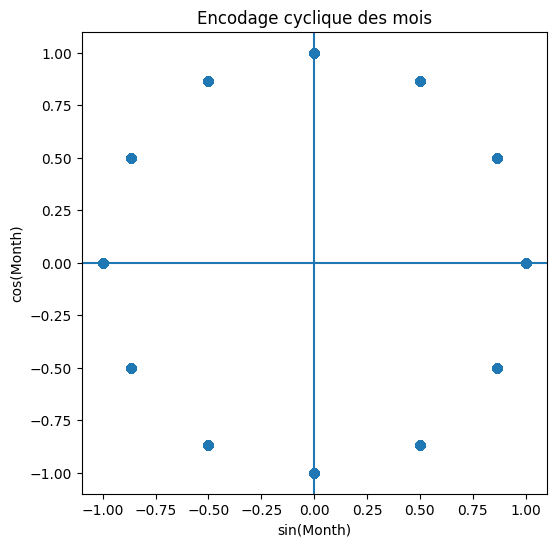

In [95]:
plt.figure(figsize=(6,6))

plt.scatter(df['RegMonth_sin'], df['RegMonth_cos'], alpha=0.5)

plt.xlabel("sin(Month)")
plt.ylabel("cos(Month)")
plt.title("Encodage cyclique des mois")

plt.axhline(0)
plt.axvline(0)

plt.show()


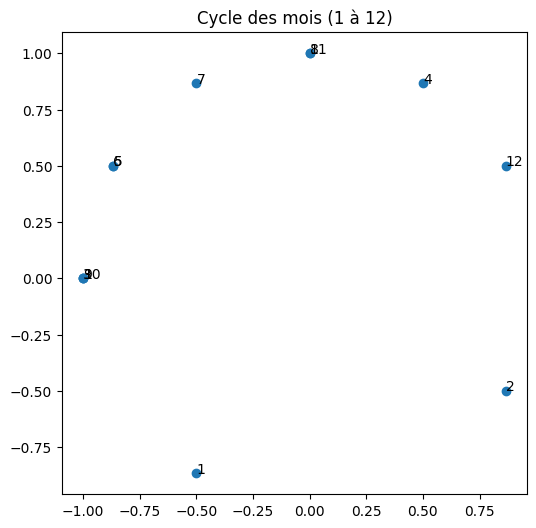

In [96]:
sample = df[['RegMonth_sin','RegMonth_cos']].head(12)

plt.figure(figsize=(6,6))
plt.scatter(sample['RegMonth_sin'], sample['RegMonth_cos'])

for i, txt in enumerate(range(1,13)):
    plt.annotate(txt, (sample.iloc[i,0], sample.iloc[i,1]))

plt.title("Cycle des mois (1 à 12)")
plt.show()


2. Visualiser RecencyCategory

2.1 Distribution des catégories

In [97]:
# df[['RecencyCategory_Recent',
#     'RecencyCategory_Moderate',
#     'RecencyCategory_Old',
#     'RecencyCategory_Very Old']].sum().plot(kind='bar')

# plt.title("Distribution des catégories de récence")
# plt.show()


# 4. Normalisation des features numériques continues

In [98]:
# Sécuriser divisions
df['CustomerTenureDays'] = df['CustomerTenureDays'].replace(0, 1)

# Remplacer inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remplacer NaN
df.fillna(df.median(numeric_only=True), inplace=True)

# Normalisation
# scaler = StandardScaler()

num_features = ['MonetaryPerDay','AvgBasketValue','PurchaseIntensity','TenureRatio',
                'ProductDiversityRatio','ReturnImpact',
                'EngagementScoreNormalized','CustomerScoreNormalized']

# df[num_features] = scaler.fit_transform(df[num_features])


# 6. Vérification des nouvelles features

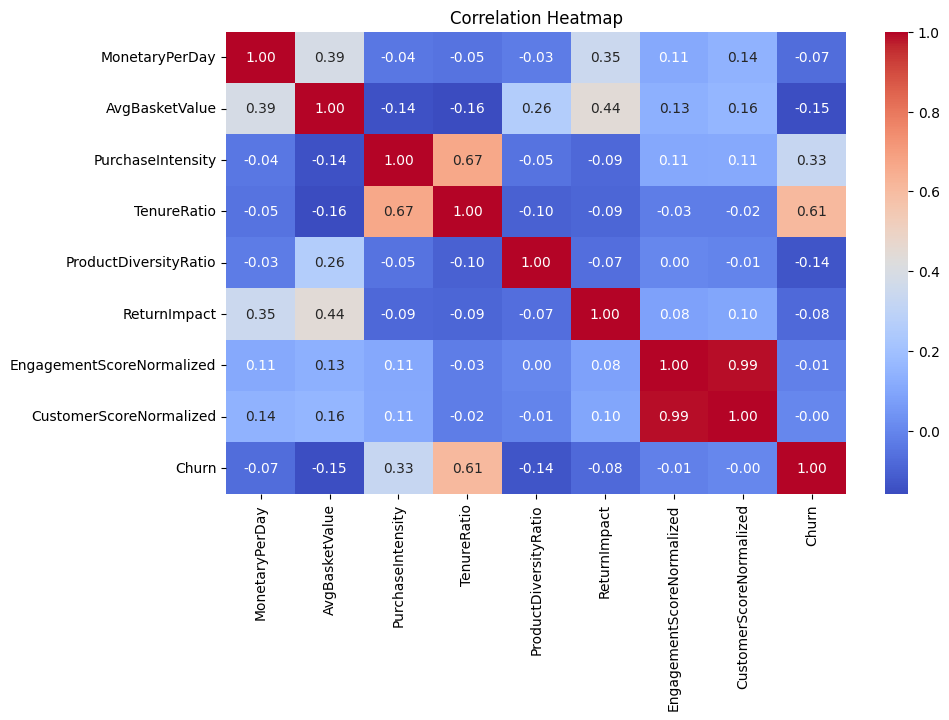

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,EngagementScoreNormalized,CustomerScore,CustomerScoreNormalized,MonetaryPerDay_log,AvgBasketValue_log,ReturnImpact_log,RegMonth_sin,RegMonth_cos,RegWeekday_sin,RegWeekday_cos
count,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,...,4372.000000,4372.000000,4372.000000,4372.000000,4372.000000,4.372000e+03,4.372000e+03,4.372000e+03,4372.000000,4372.000000
mean,15299.677722,92.047118,5.075480,1898.459701,28.839013,88.672383,-86.425754,185.179522,1122.758463,22.389288,...,11.151893,779.823496,7.530169,2.985311,5.111000,1.409338e+00,-4.498439e-02,5.669279e-02,-0.017227,-0.001453
std,1722.390705,100.765435,9.338754,8219.345141,127.323926,2689.001161,2876.398935,2881.283699,4672.682701,213.257466,...,86.866548,3287.250489,54.068517,2.011577,0.823504,2.049988e+00,7.116064e-01,6.990038e-01,0.709036,0.705123
min,12346.000000,1.000000,1.000000,-4287.630000,-4287.630000,0.000000,-168469.600000,-4287.630000,0.000000,-144.000000,...,0.011331,-1685.652000,-7.885412,-1.629947,-0.980829,-2.842171e-14,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969
25%,13812.750000,17.000000,1.000000,293.362500,10.985960,6.226414,-11.500000,31.800000,153.000000,5.475745,...,3.486268,144.573000,2.340978,1.342375,4.655427,0.000000e+00,-8.660254e-01,-5.000000e-01,-0.781831,-0.900969
50%,15300.500000,50.000000,3.000000,648.075000,16.918616,10.349780,0.790000,52.020000,365.000000,9.494392,...,5.065460,279.750000,3.295380,2.657758,5.139761,0.000000e+00,-2.449294e-16,6.123234e-17,0.000000,-0.222521
75%,16778.250000,143.000000,5.000000,1611.725000,23.542941,20.629858,6.960000,102.000000,962.250000,14.008333,...,7.249593,655.032000,4.656013,4.263904,5.604197,3.210279e+00,5.000000e-01,8.660254e-01,0.781831,0.623490
max,18287.000000,374.000000,248.000000,279489.020000,3861.000000,137554.852393,3861.000000,168469.600000,196719.000000,12540.000000,...,5505.000000,111826.808000,3363.888000,11.761505,8.430202,9.196330e+00,1.000000e+00,1.000000e+00,0.974928,1.000000


In [99]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_features + ['Churn']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

df.describe()


In [100]:
# Vérifier qu'il n'y a plus de NaN
print("Valeurs manquantes :", df.isnull().sum().sum())

# Shape finale et aperçu
print("Shape finale :", df.shape)
df.head()


Valeurs manquantes : 0
Shape finale : (4372, 69)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,EngagementScoreNormalized,CustomerScore,CustomerScoreNormalized,MonetaryPerDay_log,AvgBasketValue_log,ReturnImpact_log,RegMonth_sin,RegMonth_cos,RegWeekday_sin,RegWeekday_cos
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,24.676056,2189.852,30.842986,2.915293,4.996580,5.542287,-0.500000,-8.660254e-01,-0.974928,-0.222521
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,4.324561,1245.240,3.641053,4.546545,5.094105,5.934981,0.866025,-5.000000e-01,-0.974928,-0.222521
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,13.897297,2882.736,7.791178,7.494338,5.938277,4.749611,-1.000000,-1.836970e-16,-0.974928,-0.222521
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,1.683453,400.500,1.440647,2.377300,5.069166,0.000000,0.500000,8.660254e-01,0.433884,-0.900969
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,1.511628,322.440,7.498605,1.071149,4.518834,5.763779,-0.866025,5.000000e-01,0.000000,1.000000


In [101]:
print("Toutes les colonnes numériques ?", df.select_dtypes(include=['number']).columns)

Toutes les colonnes numériques ? Index(['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg',
       'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity',
       'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity',
       'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek',
       'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio',
       'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions',
       'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount',
       'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio',
       'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age',
       'SupportTicketsCount', 'SatisfactionScore', 'Churn',
       'MonetaryTotal_log', 'RegYear', 'RegDay', 'MonetaryPerDay',
       'AvgBasketValue', 'PurchaseIntensity', 'TenureRatio',
       'ProductDiversityRatio', 'ReturnImpact', 'EngagementScore',
       'EngagementScoreNormalized', 'CustomerScore', 'CustomerSco

# 7. Suppression des colonnes inutiles

In [102]:
df = df.drop(columns=['CustomerID'])

on peut supprimer aussi """"""""""""""""""""""""""" df = df.drop(columns=['EngagementScoreNormalized'])

# 8. Sauvegardage

In [103]:
df.to_csv('../data/processed/step3_feature_engineering.csv', index=False)

In [104]:
print("Toutes les colonnes numériques ?", df.select_dtypes(include=['object']).columns)


Toutes les colonnes numériques ? Index(['RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType',
       'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel',
       'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory',
       'ProductDiversity', 'Gender', 'AccountStatus', 'Country'],
      dtype='str')


C:\Users\chaie\AppData\Local\Temp\ipykernel_16284\734004517.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Toutes les colonnes numériques ?", df.select_dtypes(include=['object']).columns)
